# Deliverable 3: ARS V2-t on CartPole and CEM Comparison

The provided ARS tutorial derives the optimization-only ARS-V1-t update:

```text
theta <- theta + alpha / (b * sigma_R) * sum_i (J(theta + nu delta_i) - J(theta - nu delta_i)) delta_i
```

where the selected directions are the top `b` directions ranked by `max(J_plus, J_minus)`.

This notebook uses the same V1-t update and adds the V2 policy-search augmentation: running state normalization.

This notebook implements:

- paired positive/negative perturbations
- top-performing direction selection
- reward standardization with `sigma_R`
- state normalization from states observed during the perturbed rollouts
- a reward curve compared against CEM

It reruns a CEM baseline so the comparison plot is self-contained.


In [ ]:
!pip -q install mujoco mujoco-mjx mediapy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 45.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 39.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 741.0/741.0 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 42.8 MB/s eta 0:00:00


In [ ]:
import os
os.environ["MUJOCO_GL"] = "egl"

import time
import numpy as np
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
from jax import lax, random

import mujoco
from mujoco import mjx
import mediapy as media

print("JAX backend:", jax.default_backend())
print("JAX devices:", jax.devices())

Failed to import warp: No module named 'warp'
Failed to import mujoco_warp: No module named 'warp'
JAX backend: gpu
JAX devices: [CudaDevice(id=0)]


In [ ]:
# CartPole model directly in MuJoCo XML
cartpole_xml = """
<mujoco model="cartpole">
  <compiler coordinate="local" inertiafromgeom="true"/>
  <option timestep="0.01" gravity="0 0 -9.81"/>
  <worldbody>
    <light pos="0 0 3" dir="0 0 -1"/>
    <geom name="floor" type="plane" size="2 2 0.1" rgba="0.8 0.9 0.8 1"/>
    <body name="cart" pos="0 0 0.2">
      <joint name="slider" type="slide" axis="1 0 0" range="-1.5 1.5" limited="true"/>
      <geom name="cart_geom" type="box" size="0.2 0.15 0.1" rgba="0.7 0.2 0.2 1" mass="1.0"/>
      <body name="pole" pos="0 0 0.1">
        <joint name="hinge" type="hinge" axis="0 1 0" range="-90 90"/>
        <geom name="pole_geom" type="capsule" size="0.04 0.4" pos="0 0 0.4" rgba="0.2 0.7 0.2 1" mass="0.1"/>
      </body>
    </body>
  </worldbody>
  <actuator>
    <motor name="slide_motor" joint="slider" ctrlrange="-1 1" ctrllimited="true" gear="10"/>
  </actuator>
</mujoco>
"""

# Builds the CPU MuJoCo model and transfers the model definition to MJX
cart_model = mujoco.MjModel.from_xml_string(cartpole_xml)
cart_cpu_data = mujoco.MjData(cart_model)
cart_mjx_model = mjx.put_model(cart_model)


# Repeatable initial state with a small pole tilt
def make_cartpole_data(theta0=0.05):
    data = mujoco.MjData(cart_model)
    data.qpos[:] = [0.0, theta0]
    data.qvel[:] = [0.0, 0.0]
    mujoco.mj_forward(cart_model, data)
    return mjx.put_data(cart_model, data)

cart_start = make_cartpole_data()
print(f"CartPole: nq={cart_model.nq}, nv={cart_model.nv}, nu={cart_model.nu}")

CartPole: nq=2, nv=2, nu=1


## Shared policy and reward

In [ ]:
H = 500
STATE_DIM = 4
ACTION_DIM = 1
PARAM_DIM = ACTION_DIM * STATE_DIM + ACTION_DIM


# Extract the policy observation from MJX data: cart/pole positions and velocities
def state_from_data(data):
    return jnp.concatenate([data.qpos, data.qvel])


# Convert a flat parameter vector into policy weights and bias
def unpack_policy(params):
    weights = params[: ACTION_DIM * STATE_DIM].reshape(ACTION_DIM, STATE_DIM)
    bias = params[ACTION_DIM * STATE_DIM :]
    return weights, bias


# Compute the bounded motor command from the normalized state
def policy_action(params, obs, obs_mean, obs_std):
    weights, bias = unpack_policy(params)
    obs_norm = (obs - obs_mean) / obs_std
    return jnp.tanh(weights @ obs_norm + bias)


# Define the CartPole reward; higher is better and falling/drifting is penalized
def reward_from_state_action(state, action):
    x, theta, x_dot, theta_dot = state
    theta = jnp.arctan2(jnp.sin(theta), jnp.cos(theta))
    cost = (
        0.20 * x**2
        + 2.00 * theta**2
        + 0.02 * x_dot**2
        + 0.02 * theta_dot**2
        + 0.001 * jnp.sum(action**2)
    )
    return 1.0 - cost


# Roll out one feedback policy and return both total reward and state trajectory
@jax.jit
def rollout_policy(params, obs_mean, obs_std, starting_data):
    def step_fn(data, _):
        obs = state_from_data(data)
        action = policy_action(params, obs, obs_mean, obs_std)
        next_data = mjx.step(cart_mjx_model, data.replace(ctrl=action))
        next_state = state_from_data(next_data)
        reward = reward_from_state_action(next_state, action)
        return next_data, (reward, next_state)

    _, (rewards, states) = lax.scan(step_fn, starting_data, None, length=H)
    return jnp.sum(rewards), states


# Evaluate many candidate policies in parallel; this is used by CEM and ARS
@jax.jit
def batched_policy_rewards(params_batch, obs_mean, obs_std, starting_data):
    rewards, _ = jax.vmap(rollout_policy, in_axes=(0, None, None, None))(
        params_batch, obs_mean, obs_std, starting_data
    )
    return rewards


ZERO_MEAN = jnp.zeros(STATE_DIM)
UNIT_STD = jnp.ones(STATE_DIM)

# Run a quick smoke test so the notebook prints the policy shape and baseline reward
test_reward, test_states = rollout_policy(jnp.zeros(PARAM_DIM), ZERO_MEAN, UNIT_STD, cart_start)
print("Policy parameter count:", PARAM_DIM)
print("Zero-policy reward:", float(test_reward))
print("Trajectory shape:", test_states.shape)

Policy parameter count: 5
Zero-policy reward: -1568.005859375
Trajectory shape: (500, 4)


## CEM baseline for comparison

In [ ]:
# Train a linear CartPole policy with the Cross Entropy Method
def train_cem(
    key,
    iterations=60,
    population=512,
    elite_frac=0.10,
    init_std=0.50,
    min_std=0.03,
):
    # The elite count controls how many top policies refit the sampling distribution
    elite_count = max(1, int(population * elite_frac))

    # CEM starts with a Gaussian distribution over policy parameters
    mean = jnp.zeros(PARAM_DIM)
    std = jnp.ones(PARAM_DIM) * init_std
    history = []

    for it in range(iterations):
        # Sample a full population of candidate policies from the current Gaussian
        key, subkey = random.split(key)
        samples = mean + std * random.normal(subkey, (population, PARAM_DIM))

        # Evaluate every sampled policy using the batched MJX rollout function
        rewards = batched_policy_rewards(samples, ZERO_MEAN, UNIT_STD, cart_start)

        # Keep only the best-performing policies
        _, elite_idx = lax.top_k(rewards, elite_count)
        elites = samples[elite_idx]

        # Refit the Gaussian distribution to the elite policies
        mean = jnp.mean(elites, axis=0)
        std = jnp.maximum(jnp.std(elites, axis=0), min_std)

        # Store and print the best reward from this iteration for the learning curve
        best_reward = float(jnp.max(rewards))
        history.append(best_reward)
        if it % 10 == 0 or it == iterations - 1:
            print(
                f"CEM iter {it:03d} | best reward {best_reward:8.2f} | "
                f"mean std {float(jnp.mean(std)):.3f}"
            )

    return mean, jnp.array(history)


# Run the CEM optimizer and keep the final policy plus its reward history
key = random.PRNGKey(4)
cem_params, cem_history = train_cem(key)

CEM iter 000 | best reward  -450.37 | mean std 0.365
CEM iter 010 | best reward   499.43 | mean std 0.070
CEM iter 020 | best reward   499.38 | mean std 0.036
CEM iter 030 | best reward   499.41 | mean std 0.036
CEM iter 040 | best reward   499.42 | mean std 0.031
CEM iter 050 | best reward   499.45 | mean std 0.034
CEM iter 059 | best reward   499.48 | mean std 0.038


#Task 3.2: Implement ARS
(specifically the V2-t variant with state normalization). Ensure your implementation leverages your batched MJX rollouts to evaluate perturbations concurrently

#Task 3.3: Test ARS on the MJX CartPole environment to ensure algorithmic correctness and baseline sample efficiency

## ARS V2-t optimizer with state normalization

In [ ]:
# Roll out many candidate policies and return both rewards and state trajectories
@jax.jit
def batched_policy_rollouts(params_batch, obs_mean, obs_std, starting_data):
    return jax.vmap(rollout_policy, in_axes=(0, None, None, None))(
        params_batch, obs_mean, obs_std, starting_data
    )


# Update the running mean and variance used for ARS V2 state normalization
def update_running_stats(mean, var, count, batch):
    batch_mean = jnp.mean(batch, axis=0)
    batch_var = jnp.var(batch, axis=0)
    batch_count = batch.shape[0]

    delta = batch_mean - mean
    total_count = count + batch_count
    new_mean = mean + delta * batch_count / total_count

    m_a = var * count
    m_b = batch_var * batch_count
    correction = delta**2 * count * batch_count / total_count
    new_var = (m_a + m_b + correction) / total_count
    return new_mean, jnp.maximum(new_var, 1e-6), total_count


# Train a linear policy with ARS V2-t
def train_ars(
    key,
    iterations=120,
    directions=64,
    top_frac=0.25,
    step_size=0.04,
    noise=0.05,
):
    # top_b is the number of directions used in the ARS top-direction update
    top_b = max(1, int(directions * top_frac))

    # ARS optimizes one current parameter vector instead of a full distribution
    params = jnp.zeros(PARAM_DIM)

    # These variables track the running state normalizer required by V2
    obs_mean = jnp.zeros(STATE_DIM)
    obs_var = jnp.ones(STATE_DIM)
    obs_count = jnp.array(1e-4)
    history = []

    for it in range(iterations):
        # Normalize states using statistics gathered from previous rollouts
        obs_std = jnp.sqrt(obs_var) + 1e-6

        # Sample random search directions in policy-parameter space
        key, subkey = random.split(key)
        deltas = random.normal(subkey, (directions, PARAM_DIM))

        # Build paired positive and negative perturbations: theta +/- nu * delta
        plus_params = params + noise * deltas
        minus_params = params - noise * deltas
        candidates = jnp.concatenate([plus_params, minus_params], axis=0)

        # Evaluate all 2N perturbed policies in parallel
        rewards, candidate_states = batched_policy_rollouts(candidates, obs_mean, obs_std, cart_start)

        # ARS V2 uses a running normalizer from states encountered during training
        # These states are from the 2N perturbed rollouts evaluated in this iteration
        flat_states = candidate_states.reshape((-1, STATE_DIM))
        obs_mean, obs_var, obs_count = update_running_stats(
            obs_mean, obs_var, obs_count, flat_states
        )

        # Split rewards back into positive and negative perturbation scores
        rewards_pos = rewards[:directions]
        rewards_neg = rewards[directions:]

        # Rank directions by the better sign, exactly as in ARS-V1-t
        _, elite_idx = lax.top_k(jnp.maximum(rewards_pos, rewards_neg), top_b)

        # Keep only the elite directions and compute the symmetric reward difference
        elite_diffs = rewards_pos[elite_idx] - rewards_neg[elite_idx]
        elite_deltas = deltas[elite_idx]

        # Normalize the update by the standard deviation of elite rewards
        elite_rewards = jnp.concatenate([rewards_pos[elite_idx], rewards_neg[elite_idx]])
        sigma_r = jnp.std(elite_rewards) + 1e-6

        # Apply the ARS update: alpha / (b * sigma_R) times the weighted directions
        step = jnp.tensordot(elite_diffs, elite_deltas, axes=1)
        params = params + (step_size / (top_b * sigma_r)) * step

        # Evaluate the updated policy for the learning curve
        obs_std = jnp.sqrt(obs_var) + 1e-6
        current_reward, _ = rollout_policy(params, obs_mean, obs_std, cart_start)
        current_reward = float(current_reward)
        history.append(current_reward)
        if it % 10 == 0 or it == iterations - 1:
            print(f"ARS iter {it:03d} | reward {current_reward:8.2f} | sigma_R {float(sigma_r):.3f}")

    return params, (obs_mean, jnp.sqrt(obs_var) + 1e-6), jnp.array(history)


# Run ARS and save both the learned policy and the final normalization statistics
key = random.PRNGKey(3)
ars_params, ars_norm, ars_history = train_ars(key)

ARS iter 000 | reward -1501.52 | sigma_R 185.297
ARS iter 010 | reward  -899.42 | sigma_R 235.312
ARS iter 020 | reward  -664.26 | sigma_R 208.772
ARS iter 030 | reward   259.92 | sigma_R 372.845
ARS iter 040 | reward   475.90 | sigma_R 446.200
ARS iter 050 | reward   488.49 | sigma_R 48.138
ARS iter 060 | reward   484.76 | sigma_R 72.722
ARS iter 070 | reward   494.29 | sigma_R 4.764
ARS iter 080 | reward   496.16 | sigma_R 4.629
ARS iter 090 | reward   497.31 | sigma_R 3.177
ARS iter 100 | reward   497.90 | sigma_R 0.960
ARS iter 110 | reward   498.45 | sigma_R 1.074
ARS iter 119 | reward   498.83 | sigma_R 0.740


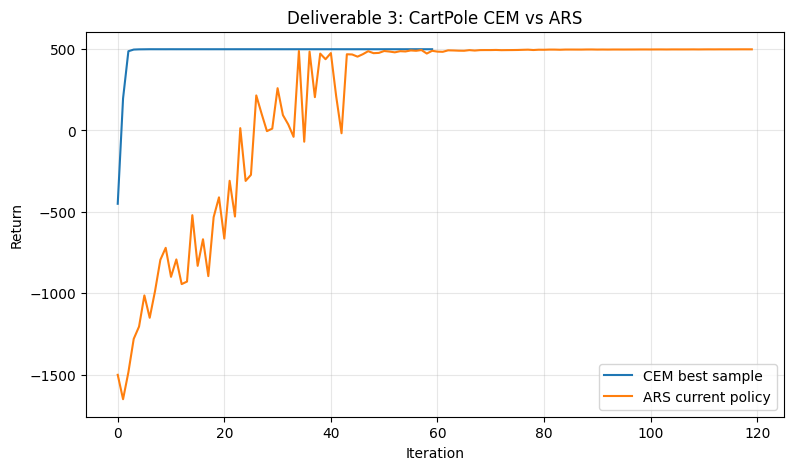

Approximate CEM environment steps: 15,360,000
Approximate ARS environment steps: 7,740,000


In [ ]:
# Plot CEM and ARS
plt.figure(figsize=(9, 5))
plt.plot(np.asarray(cem_history), label="CEM best sample")
plt.plot(np.asarray(ars_history), label="ARS current policy")
plt.xlabel("Iteration")
plt.ylabel("Return")
plt.title("Deliverable 3: CartPole CEM vs ARS")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Estimate total environment steps so the report can discuss sample efficiency
cem_population = 512
ars_directions = 64
cem_steps = len(cem_history) * cem_population * H
ars_steps = len(ars_history) * (2 * ars_directions + 1) * H
print(f"Approximate CEM environment steps: {cem_steps:,}")
print(f"Approximate ARS environment steps: {ars_steps:,}")

## Short analysis for the report

ARS scales better than standard CEM because each update estimates a direction in parameter space using paired perturbations instead of fitting a full sampling distribution from elites. The top-direction update and reward normalization reduce sensitivity to noisy rollouts, while state normalization keeps the linear policy from overreacting to state variables with different magnitudes.


In [ ]:
# Render a trained CartPole policy by replaying its MJX trajectory in CPU MuJoCo
def render_policy_video(params, obs_mean, obs_std, title, fps=30):
    # First generate the trajectory with the learned feedback policy
    reward, states = rollout_policy(params, obs_mean, obs_std, cart_start)
    states = np.asarray(states)

    # Create a MuJoCo renderer for RGB frames
    renderer = mujoco.Renderer(cart_model, height=480, width=640)
    frames = []
    render_step = max(1, int((1 / fps) / cart_model.opt.timestep))

    # Copy each saved MJX state into CPU MuJoCo and render video frames
    cpu_data = mujoco.MjData(cart_model)
    for i in range(H):
        if i % render_step == 0:
            cpu_data.qpos[:] = states[i, :2]
            cpu_data.qvel[:] = states[i, 2:]
            mujoco.mj_forward(cart_model, cpu_data)
            renderer.update_scene(cpu_data)
            frames.append(renderer.render().copy())

    renderer.close()
    print(f"{title} return: {float(reward):.2f}")
    media.show_video(frames, fps=fps)


# Show the CEM policy video
render_policy_video(cem_params, ZERO_MEAN, UNIT_STD, "CEM CartPole policy")

# Show the ARS policy video using the learned ARS normalizer
render_policy_video(ars_params, ars_norm[0], ars_norm[1], "ARS CartPole policy")

CEM CartPole policy return: 499.44


This browser does not support the video tag.


ARS CartPole policy return: 498.83


This browser does not support the video tag.
